# Trader Performance Analysis Based on Bitcoin Market Sentiment

## Objective

The objective of this project is to analyze how Bitcoin market sentiment impacts trader behavior and profitability on Hyperliquid.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [43]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print(trades.shape)
print(sentiment.shape)

(211224, 16)
(2644, 4)


In [44]:
print("TRADES COLUMNS")
print(trades.columns)

print("\nSENTIMENT COLUMNS")
print(sentiment.columns)

TRADES COLUMNS
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

SENTIMENT COLUMNS
Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


## Data Loading and Initial Exploration

In this section, both datasets are loaded and inspected to understand their structure and available features.

# Check dataset dimensions

In [45]:
print("Trades Dataset Shape:", trades.shape)
print("Sentiment Dataset Shape:", sentiment.shape)

Trades Dataset Shape: (211224, 16)
Sentiment Dataset Shape: (2644, 4)


# Display first few records

In [46]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [47]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## Data Cleaning

Before analysis, date columns need to be converted into datetime format so that both datasets can be merged correctly.

# Convert date columns

In [48]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])

sentiment['date'] = pd.to_datetime(sentiment['date'])

# Create trading date column

In [49]:
trades['trade_date'] = trades['Timestamp'].dt.date

sentiment['date'] = sentiment['date'].dt.date

# Merge datasets on date

In [50]:
merged_df = pd.merge(
    trades,
    sentiment,
    left_on='trade_date',
    right_on='date',
    how='left'
)

print(merged_df.shape)

(211224, 21)


# Check missing sentiment values

In [51]:
merged_df['classification'].isnull().sum()

np.int64(211224)

In [52]:
trades[['Timestamp', 'trade_date']].head()

,Timestamp,trade_date
0,1970-01-01 00:28:50,1970-01-01
1,1970-01-01 00:28:50,1970-01-01
2,1970-01-01 00:28:50,1970-01-01
3,1970-01-01 00:28:50,1970-01-01
4,1970-01-01 00:28:50,1970-01-01


In [53]:
sentiment[['date', 'classification']].head()

,date,classification
0,2018-02-01,Fear
1,2018-02-02,Extreme Fear
2,2018-02-03,Fear
3,2018-02-04,Extreme Fear
4,2018-02-05,Extreme Fear


In [54]:
print(trades['trade_date'].dtype)
print(sentiment['date'].dtype)

object
object


In [55]:
trades['Timestamp'].head()

0   1970-01-01 00:28:50
1   1970-01-01 00:28:50
2   1970-01-01 00:28:50
3   1970-01-01 00:28:50
4   1970-01-01 00:28:50
Name: Timestamp, dtype: datetime64[ns]

In [56]:
trades['Timestamp'].describe()

count                           211224
mean     1970-01-01 00:28:57.744290421
min                1970-01-01 00:28:00
25%                1970-01-01 00:29:00
50%                1970-01-01 00:29:00
75%                1970-01-01 00:29:00
max                1970-01-01 00:29:10
Name: Timestamp, dtype: object

In [57]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,1970-01-01
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,1970-01-01
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,1970-01-01
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,1970-01-01
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,1970-01-01


In [58]:
trades[['Timestamp IST']].head()

,Timestamp IST
0,02-12-2024 22:50
1,02-12-2024 22:50
2,02-12-2024 22:50
3,02-12-2024 22:50
4,02-12-2024 22:50


In [59]:
trades['Timestamp IST'].dtype

<StringDtype(storage='python', na_value=nan)>

# Convert Timestamp IST to datetime

In [60]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

# Create date column

trades['trade_date'] = trades['Timestamp IST'].dt.date

# Convert sentiment date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [61]:
trades[['Timestamp IST','trade_date']].head()

,Timestamp IST,trade_date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


## Data Preparation

# The trade dataset and sentiment dataset were aligned using trading dates. This allows each trade to be associated with the prevailing Bitcoin market sentiment on that day.

In [62]:
merged_df = pd.merge(
    trades,
    sentiment,
    left_on='trade_date',
    right_on='date',
    how='left'
)

print(merged_df.shape)

(211224, 21)


In [63]:
merged_df['classification'].isnull().sum()

np.int64(6)

## Market Sentiment Distribution

This section examines how trading activity is distributed across different market sentiment categories.

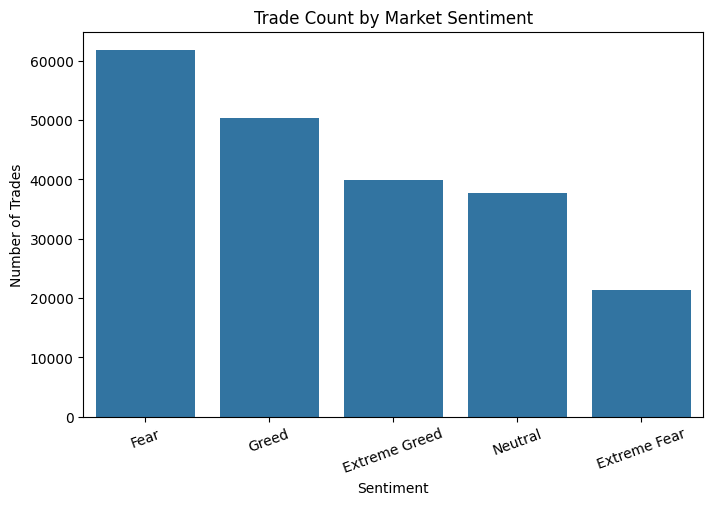

In [64]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged_df,
    x='classification',
    order=merged_df['classification'].value_counts().index
)

plt.title("Trade Count by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=20)

plt.show()

### Observation

Fear sentiment recorded the highest trading activity with nearly 60,000 trades, while Extreme Fear had the lowest participation with around 20,000 trades. This suggests that traders tend to remain active during fearful market conditions rather than staying completely out of the market.

## Profitability Across Market Sentiments

To understand whether market sentiment impacts trading performance, the average realized profit and loss (PnL) is analyzed across different sentiment categories.

In [65]:
# Average PnL by sentiment

avg_pnl = merged_df.groupby('classification')['Closed PnL'].mean().sort_values(ascending=False)

print(avg_pnl)

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64


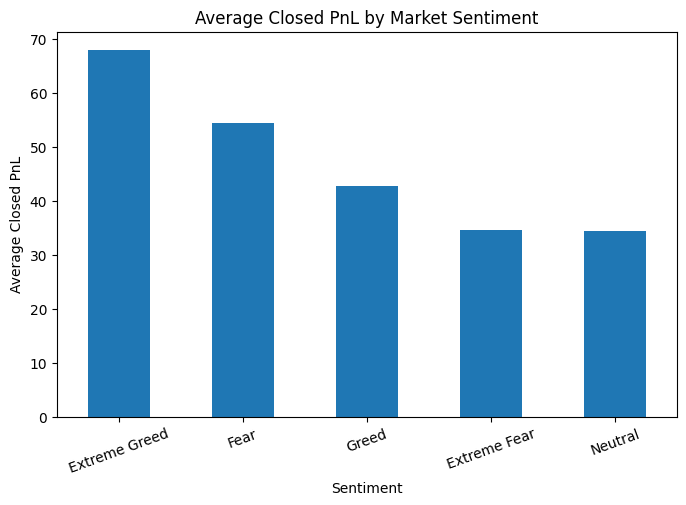

In [66]:
plt.figure(figsize=(8,5))

avg_pnl.plot(kind='bar')

plt.title('Average Closed PnL by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Closed PnL')

plt.xticks(rotation=20)

plt.show()

# Average PnL by sentiment

### Observation

Extreme Greed recorded the highest average Closed PnL among all sentiment categories, indicating that traders generally performed better during strongly bullish market conditions.

Interestingly, Fear ranked second in terms of average profitability. This may suggest that some traders were able to capitalize on market corrections and volatility during fearful periods.

Neutral and Extreme Fear sentiment showed the lowest average profits, indicating relatively weaker trading performance under these market conditions.

## Total Profit Analysis

While average profit measures trade efficiency, total profit helps identify which sentiment regimes contributed the most overall profitability.

In [67]:
total_pnl = merged_df.groupby('classification')['Closed PnL'].sum().sort_values(ascending=False)

print(total_pnl)

classification
Fear             3.357155e+06
Extreme Greed    2.715171e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Extreme Fear     7.391102e+05
Name: Closed PnL, dtype: float64


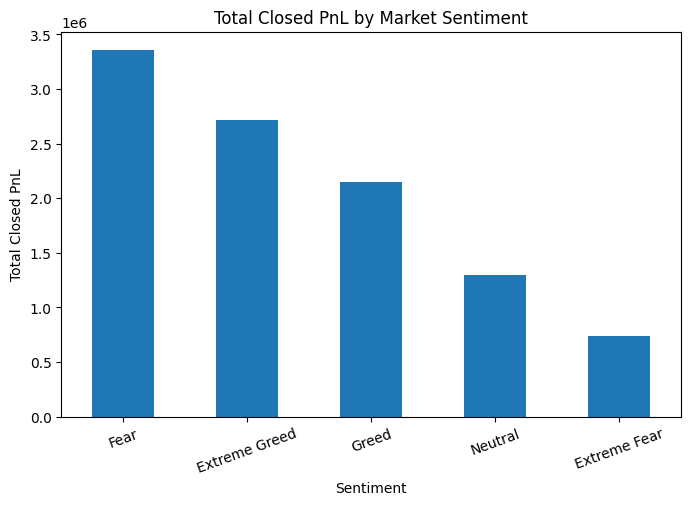

In [68]:
plt.figure(figsize=(8,5))

total_pnl.plot(kind='bar')

plt.title('Total Closed PnL by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Total Closed PnL')

plt.xticks(rotation=20)

plt.show()

### Observation

Fear sentiment generated the highest total profit across all trades, followed by Extreme Greed and Greed.

Although Extreme Greed had the highest average profit per trade, Fear contributed the largest overall profitability due to significantly higher trading activity. This indicates that both market participation and trade performance play an important role in determining total returns.

## Win Rate Analysis

To evaluate trading consistency, a win rate metric was calculated by identifying trades with a positive Closed PnL.

In [69]:
# Create win/loss flag

merged_df['win_trade'] = merged_df['Closed PnL'] > 0

# Calculate win rate

win_rate = (
    merged_df
    .groupby('classification')['win_trade']
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(win_rate)

classification
Extreme Greed    46.494299
Fear             42.076750
Neutral          39.699093
Greed            38.482794
Extreme Fear     37.060748
Name: win_trade, dtype: float64


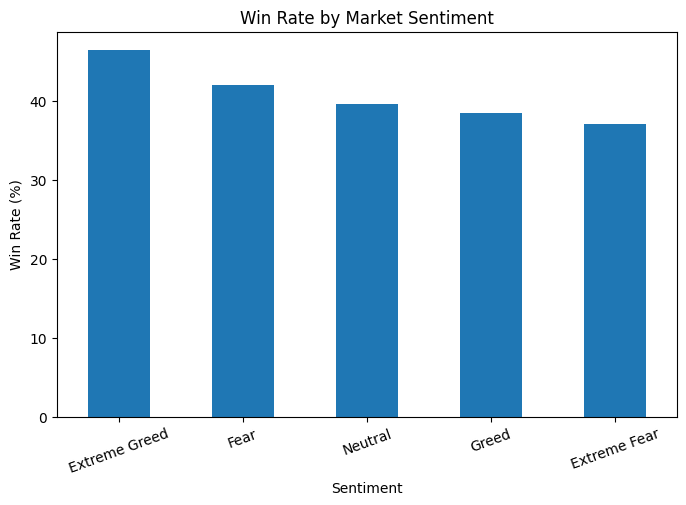

In [70]:
plt.figure(figsize=(8,5))

win_rate.plot(kind='bar')

plt.title('Win Rate by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate (%)')

plt.xticks(rotation=20)

plt.show()

### Observation

Extreme Greed achieved the highest win rate at approximately 46.5%, indicating that traders were more likely to close profitable positions during strongly bullish market conditions.

Fear ranked second with a win rate of about 42.1%, suggesting that market volatility during fearful periods may also create profitable trading opportunities.

Extreme Fear recorded the lowest win rate, indicating that highly negative market sentiment may present more challenging trading conditions.

## Trade Size Analysis

Trade size can provide insights into trader confidence and risk-taking behavior under different market sentiment conditions.

In [71]:
avg_size = (
    merged_df
    .groupby('classification')['Size USD']
    .mean()
    .sort_values(ascending=False)
)

print(avg_size)

classification
Fear             7816.109931
Greed            5736.884375
Extreme Fear     5349.731843
Neutral          4782.732661
Extreme Greed    3112.251565
Name: Size USD, dtype: float64


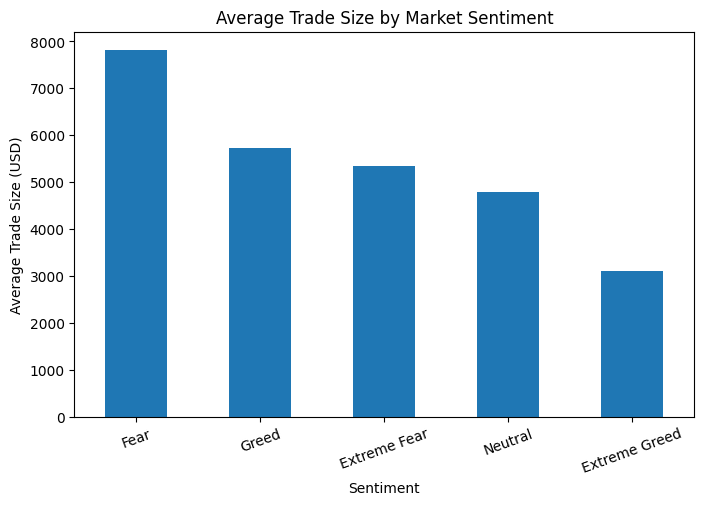

In [72]:
plt.figure(figsize=(8,5))

avg_size.plot(kind='bar')

plt.title('Average Trade Size by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Trade Size (USD)')

plt.xticks(rotation=20)

plt.show()

## Statistical Summary

To gain a better understanding of the numerical characteristics of the dataset, summary statistics were generated for key trading variables.

In [73]:
merged_df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,timestamp,value
count,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,211224,2.112180e+05,211218.000000
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-31 12:04:22.915010,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1970-01-01 00:28:57.744290421,1.738301e+09,51.649656
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1970-01-01 00:28:00,1.682919e+09,10.000000
25%,4.854700,2.940000e+00,1.937900e+02,2024-12-31 21:00:45,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1970-01-01 00:29:00,1.735623e+09,33.000000
50%,18.280000,3.200000e+01,5.970450e+02,2025-02-24 18:55:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1970-01-01 00:29:00,1.740375e+09,49.000000
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-02 18:22:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1970-01-01 00:29:00,1.743572e+09,72.000000
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1970-01-01 00:29:10,1.746077e+09,94.000000
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,NaN,8.029302e+06,21.012784


In [74]:
merged_df[['Closed PnL', 'Size USD']].describe()

,Closed PnL,Size USD
count,211224.000000,2.112240e+05
mean,48.749001,5.639451e+03
std,919.164828,3.657514e+04
min,-117990.104100,0.000000e+00
25%,0.000000,1.937900e+02
50%,0.000000,5.970450e+02
75%,5.792797,2.058960e+03
max,135329.090100,3.921431e+06


### Observation

Fear sentiment recorded the highest average trade size at approximately $7,816, indicating that traders deployed larger amounts of capital during uncertain market conditions.

In contrast, Extreme Greed had the smallest average trade size despite generating the highest average profit per trade. This suggests that strong profitability during bullish periods was not necessarily driven by larger position sizes.

Overall, the results indicate that trader risk-taking behavior varies across sentiment regimes.

# Key Findings

1. Fear sentiment accounted for the highest trading activity, with nearly 60,000 trades.

2. Extreme Greed generated the highest average profit per trade, indicating stronger trading performance during bullish market conditions.

3. Fear produced the highest total profit due to substantially higher trading participation.

4. Extreme Greed achieved the highest win rate (46.5%), while Extreme Fear recorded the lowest.

5. Traders deployed the largest average position sizes during Fear periods, suggesting higher conviction or attempts to capitalize on volatility.

# Recommendations

1. Market sentiment should be considered as an additional feature when evaluating trading opportunities.

2. Extreme Greed periods historically produced stronger profitability and higher win rates, making them important market conditions for strategy evaluation.

3. Risk controls should be emphasized during Fear periods because traders tend to deploy larger amounts of capital.

4. Combining sentiment indicators with price action and volatility metrics may improve trading decision-making and risk management.

# Conclusion

This analysis explored the relationship between Bitcoin market sentiment and trader performance on Hyperliquid.

The findings indicate that market sentiment has a measurable impact on trading outcomes. Fear periods were associated with higher trading activity and larger position sizes, while Extreme Greed periods delivered the strongest average profitability and win rates.

These results suggest that sentiment can serve as a valuable contextual indicator for understanding trader behavior and enhancing trading strategies.